# Multiscale loss run (Linea 1) — diagnostics vs the seed ruler
Training run `best_sweep_multiscale_loss` (config_best_sweep_multiscale_loss.yaml, loss over all 4 scales,
weights [5,1,1,1] finest-first). Same diagnostics as `visualize_finetuned_fixed_gt_warmstart.ipynb`.

Judged against the seed ruler (results/seed_table.csv): the best_CSI band of the 5 baseline seeds.
Above the band = real improvement, inside = tie, below = regression.


In [ ]:
import sys, os
os.environ.setdefault('OMP_NUM_THREADS', '1')   # local torch crashes if multithreaded
os.environ.setdefault('MKL_NUM_THREADS', '1')

_proj_db = r'C:\Users\marrocol\AppData\Local\miniforge3\envs\mswe-gnn\Lib\site-packages\pyproj\proj_dir\share\proj'
os.environ.setdefault('PROJ_DATA', _proj_db)
os.environ.setdefault('PROJ_LIB',  _proj_db)

# Resolve the repo root robustly (works in VS Code and nbconvert, any start cwd)
try:
    REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__vsc_ipynb_file__), '..'))
except NameError:
    _here = os.getcwd()
    REPO_ROOT = _here if os.path.isdir(os.path.join(_here, 'database')) \
                else os.path.abspath(os.path.join(_here, '..'))
assert os.path.isdir(os.path.join(REPO_ROOT, 'database')), f'Not the repo root: {REPO_ROOT}'
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass   # already set, or parallel work started (re-running this cell in a live kernel)
import wandb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from utils.load import read_config
from utils.miscellaneous import get_model, fix_dict_in_config
from utils.dataset import create_model_dataset, get_temporal_test_dataset_parameters, to_temporal_dataset
from utils.visualization import PlotRollout
from training.train import LightningTrainer

torch.backends.cudnn.deterministic = True
torch.set_float32_matmul_precision('high')
print('Repo root:', REPO_ROOT)

## Models to compare
The two multiscale checkpoints, plus the seed-666 baseline best-CSI for side-by-side reference.
The multiscale seed variants (seed 1, 200) are listed too and skipped while their files are missing.

In [ ]:
CONFIG       = 'config_best_sweep.yaml'   # architecture is auto-detected per checkpoint
DATASET_NAME = 'ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart'

MODELS = [
    {'name': 'baseline_666_bestCSI',      'checkpoint': os.path.join(REPO_ROOT, 'results', 'best_sweep_new_gt_bestCSI.h5')},
    {'name': 'multiscale_666_bestvalloss','checkpoint': os.path.join(REPO_ROOT, 'results', 'best_sweep_multiscale_loss.h5')},
    {'name': 'multiscale_666_bestCSI',    'checkpoint': os.path.join(REPO_ROOT, 'results', 'best_sweep_multiscale_loss_bestCSI.h5')},
    {'name': 'multiscale_seed1_bestCSI',  'checkpoint': os.path.join(REPO_ROOT, 'results', 'best_sweep_multiscale_loss_seed1_bestCSI.h5')},
    {'name': 'multiscale_seed200_bestCSI','checkpoint': os.path.join(REPO_ROOT, 'results', 'best_sweep_multiscale_loss_seed200_bestCSI.h5')},
]

for m in MODELS:
    exists = os.path.exists(m['checkpoint'])
    size = f"{os.path.getsize(m['checkpoint'])/1e6:.1f} MB" if exists else 'MISSING'
    print(f"{m['name']:<28} exists={exists!s:<6} {size:>10}  {m['checkpoint']}")

baseline_666_bestCSI         exists=True       2.5 MB  c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\results\best_sweep_new_gt_bestCSI.h5
multiscale_666_bestvalloss   exists=True       2.5 MB  c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\results\best_sweep_multiscale_loss.h5
multiscale_666_bestCSI       exists=True       2.5 MB  c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\results\best_sweep_multiscale_loss_bestCSI.h5
multiscale_seed1_bestCSI     exists=False     MISSING  c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\results\best_sweep_multiscale_loss_seed1_bestCSI.h5
multiscale_seed200_bestCSI   exists=False     MISSING  c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\results\best_sweep_multiscale_loss_seed200_bestCSI.h5


## The ruler (from seed_ruler_table.ipynb)

In [ ]:
seed_table = pd.read_csv('results/seed_table.csv')
ruler = seed_table[seed_table.ckpt == 'best_CSI']
RULER_LO, RULER_HI = ruler.CSI_005.min(), ruler.CSI_005.max()
print(f'best_CSI ruler, n={len(ruler)} seeds:')
print(f"  CSI@0.05: mean={ruler.CSI_005.mean():.4f} +- {ruler.CSI_005.std(ddof=1):.4f}   band [{RULER_LO:.4f}, {RULER_HI:.4f}]")
print(f"  RMSE_WD : mean={ruler.RMSE_WD.mean():.4f} +- {ruler.RMSE_WD.std(ddof=1):.4f}")
print(f"  CSI@0.30: mean={ruler.CSI_03.mean():.4f} +- {ruler.CSI_03.std(ddof=1):.4f}")

best_CSI ruler, n=5 seeds:
  CSI@0.05: mean=0.7710 +- 0.0378   band [0.7225, 0.8134]
  RMSE_WD : mean=0.1632 +- 0.0228
  CSI@0.30: mean=0.7854 +- 0.0433


## Load shared config and dataset
Same test rollout is reused for every checkpoint, so the comparison is apples-to-apples.

In [ ]:
cfg = read_config(CONFIG)
cfg['dataset_parameters']['test_dataset_name']  = DATASET_NAME
cfg['dataset_parameters']['train_dataset_name'] = DATASET_NAME

wandb.init(mode='disabled', project='mswe-gnn', config=cfg)
fix_dict_in_config(wandb)
config = wandb.config

device = torch.device('cpu')

_, _, test_dataset, scalers = create_model_dataset(
    scalers=config.scalers, device=device,
    **config.dataset_parameters,
    **config.selected_node_features,
    **config.selected_edge_features
)

temporal_test_dataset_parameters = get_temporal_test_dataset_parameters(
    config, config.temporal_dataset_parameters
)

temporal_test_dataset = to_temporal_dataset(
    test_dataset, rollout_steps=-1, **temporal_test_dataset_parameters
)

num_node_features = temporal_test_dataset[0].x.size(-1)
num_edge_features = temporal_test_dataset[0].edge_attr.size(-1)

print('Test size:', len(test_dataset))
print('WD shape: ', test_dataset[0].WD.shape)

The validation dataset you are using is the training one. Careful!
Test size: 1
WD shape:  torch.Size([30079, 119])


## Load each checkpoint and run inference
Architecture (hid_features, K) is auto-detected from each checkpoint's state_dict.

In [ ]:
def load_model_from_checkpoint(checkpoint_path):
    model_parameters = dict(config.models)
    model_type = model_parameters.pop('model_type')
    if model_type == 'MSGNN':
        model_parameters['num_scales'] = test_dataset[0].mesh.num_meshes

    ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    sd   = ckpt['state_dict']
    hid  = sd['model.edge_encoder.0.weight'].shape[0]

    proc_ids = sorted(set(
        int(k.split('.')[2]) for k in sd
        if k.startswith('model.gnn_processor.') and 'filter_matrix.' in k
    ))
    K_list = [
        sum(1 for k in sd if f'model.gnn_processor.{i}.filter_matrix.' in k and k.endswith('.weight')) - 1
        for i in proc_ids
    ]
    model_parameters['hid_features'] = hid
    model_parameters['K']            = K_list

    model = get_model(model_type)(
        num_node_features=num_node_features,
        num_edge_features=num_edge_features,
        previous_t=temporal_test_dataset_parameters['previous_t'],
        device=device,
        **model_parameters
    ).to(device)

    plmodule_kwargs = {
        'model': model,
        'lr_info': config['lr_info'],
        'trainer_options': config.trainer_options,
        'temporal_test_dataset_parameters': temporal_test_dataset_parameters
    }
    plmodule = LightningTrainer.load_from_checkpoint(
        checkpoint_path, map_location=device, **plmodule_kwargs
    )
    model = plmodule.model.to(device)
    model.eval()
    return model, hid, K_list, ckpt.get('epoch', -1)


results = {}
for m in MODELS:
    name, ckpt_path = m['name'], m['checkpoint']
    if not os.path.exists(ckpt_path):
        print(f'[skip] {name}: checkpoint not found')
        continue
    print(f'Loading {name} ...')
    model, hid, K_list, epoch = load_model_from_checkpoint(ckpt_path)

    plot_rollout = PlotRollout(
        model, test_dataset[0], scalers=scalers,
        warmup_steps=0, **temporal_test_dataset_parameters
    )

    rollout_loss = plot_rollout._get_rollout_loss(type_loss='RMSE')
    loss_mean = rollout_loss.mean(0)
    rmse_wd = loss_mean[0].item() if loss_mean.ndim > 0 else loss_mean.item()

    csi_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.20, 0.30, 0.50]
    csi_curve = [plot_rollout._get_CSI(water_threshold=t).nanmean().item() for t in csi_thresholds]

    csi_time_005 = plot_rollout._get_CSI(water_threshold=0.05).detach().cpu().numpy()
    csi_time_03  = plot_rollout._get_CSI(water_threshold=0.30).detach().cpu().numpy()
    if csi_time_005.ndim > 1:
        csi_time_005 = np.nanmean(csi_time_005, axis=0)
        csi_time_03  = np.nanmean(csi_time_03, axis=0)

    results[name] = {
        'hid_features': hid,
        'K': K_list,
        'epoch': epoch,
        'rmse_wd': rmse_wd,
        'csi_005': csi_curve[csi_thresholds.index(0.05)],
        'csi_03':  csi_curve[csi_thresholds.index(0.30)],
        'csi_thresholds': csi_thresholds,
        'csi_curve': csi_curve,
        'csi_time_005': csi_time_005,
        'csi_time_03': csi_time_03,
        'plot_rollout': plot_rollout,
    }
    print(f'  epoch={epoch} hid={hid} K={K_list}  RMSE_WD={rmse_wd:.4f}  CSI@0.05={results[name]["csi_005"]:.4f}  CSI@0.30={results[name]["csi_03"]:.4f}')

Loading baseline_666_bestCSI ...
  epoch=632 hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.1600  CSI@0.05=0.7409  CSI@0.30=0.7940
Loading multiscale_666_bestvalloss ...
  epoch=767 hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.1512  CSI@0.05=0.7826  CSI@0.30=0.8483
Loading multiscale_666_bestCSI ...
  epoch=230 hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.1857  CSI@0.05=0.8150  CSI@0.30=0.8356
[skip] multiscale_seed1_bestCSI: checkpoint not found
[skip] multiscale_seed200_bestCSI: checkpoint not found


## Summary table — placed on the ruler

In [ ]:
header = f"{'Model':<28} {'epoch':>6} {'RMSE_WD':>9} {'CSI@0.05':>9} {'CSI@0.30':>9}  vs ruler [{RULER_LO:.3f}, {RULER_HI:.3f}]"
print(header)
print('-' * len(header))
for name, r in results.items():
    c = r['csi_005']
    verdict = 'ABOVE (improvement)' if c > RULER_HI else ('BELOW (regression)' if c < RULER_LO else 'inside (tie)')
    print(f"{name:<28} {r['epoch']:>6} {r['rmse_wd']:>9.4f} {c:>9.4f} {r['csi_03']:>9.4f}  {verdict}")

Model                         epoch   RMSE_WD  CSI@0.05  CSI@0.30  vs ruler [0.722, 0.813]
------------------------------------------------------------------------------------------
baseline_666_bestCSI            632    0.1600    0.7409    0.7940  inside (tie)
multiscale_666_bestvalloss      767    0.1512    0.7826    0.8483  inside (tie)
multiscale_666_bestCSI          230    0.1857    0.8150    0.8356  ABOVE (improvement)


## Plateau evidence — where to cut the epoch budget for the K=8 run
Reads the best epoch stored in every multiscale checkpoint (all 3 seeds, both checkpoint types).
The K=8 run gets max_epochs = max(best epochs) + margin, with T_max = max_epochs so the cosine
schedule completes within the budget.

In [ ]:
import glob

ckpt_files = sorted(glob.glob('results/best_sweep_multiscale_loss*.h5'))
epochs = {}
for f in ckpt_files:
    ck = torch.load(f, map_location='cpu', weights_only=False)
    epochs[os.path.basename(f)] = int(ck.get('epoch', -1))

print(f"{'checkpoint':<52} best epoch")
for name, e in epochs.items():
    print(f'{name:<52} {e:>6}')

if epochs:
    e_max = max(epochs.values())
    MARGIN = 150   # so the checkpoint callbacks are not racing the wall
    budget = int(np.ceil((e_max + MARGIN) / 50) * 50)
    print(f'\nmax best epoch = {e_max}')
    print(f'suggested K=8 budget: max_epochs = T_max = {budget}')
    print('(patience 300 stays as a second safety net; with <3 seeds present this is provisional)')

In [ ]:
# Val-loss plateau from the W&B histories of the multiscale runs (needs internet + wandb login).
# Plateau = first epoch where the smoothed val_loss gets within TOL of its minimum and stays there.
# NOTE: the API returns empty configs for this project's runs (offline-sync quirk),
# so the multiscale runs are selected by NAME ('multiscale' in the run name).
API_PROJECT = 'mmarrocolo-tu-delft/mswe-gnn-ahr-finetune'
SMOOTH_WIN  = 25     # epochs, rolling median (val curves are very noisy)
TOL         = 0.02   # within 2% of the smoothed minimum counts as "arrived"

api = wandb.Api()
all_runs = list(api.runs(API_PROJECT))
ms_runs = [r for r in all_runs if 'multiscale' in r.name.lower()]
print('multiscale runs selected:')
for r in ms_runs:
    print(f'  {r.id}  {r.name:<50} {r.state}')

fig, ax = plt.subplots(figsize=(11, 5))
plateaus = {}
for run in ms_runs:
    h = run.history(keys=['epoch', 'val_loss'], samples=4000, pandas=True)
    h = h.dropna(subset=['val_loss']).sort_values('epoch')
    if len(h) == 0:
        print(f'[skip] {run.name} ({run.id}): no val_loss history (partial sync? re-run wandb sync)')
        continue
    label = run.name

    smooth = h['val_loss'].rolling(SMOOTH_WIN, center=True, min_periods=5).median()
    vmin = smooth.min()
    arrived = smooth <= vmin * (1 + TOL)
    plateau_epoch = int(h['epoch'][arrived].iloc[0]) if arrived.any() else int(h['epoch'].iloc[-1])
    argmin_epoch = int(h['epoch'][smooth.idxmin()]) if not np.isnan(vmin) else -1
    plateaus[label] = (plateau_epoch, argmin_epoch)

    line, = ax.plot(h['epoch'], h['val_loss'], alpha=0.25)
    ax.plot(h['epoch'], smooth, color=line.get_color(), label=label)
    ax.axvline(plateau_epoch, color=line.get_color(), ls='--', alpha=0.7)

ax.set_xlabel('epoch'); ax.set_ylabel('val_loss'); ax.set_yscale('log')
ax.set_title(f'val_loss (raw + rolling-median {SMOOTH_WIN}) — dashed = plateau epoch (within {TOL:.0%} of min)')
ax.grid(alpha=0.3)
if plateaus:
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"{'run':<55} {'plateau epoch':>14} {'smoothed argmin':>16}")
for label, (pe, ae) in plateaus.items():
    print(f'{label:<55} {pe:>14} {ae:>16}')
if plateaus:
    worst = max(pe for pe, _ in plateaus.values())
    print(f'\nlatest plateau across seeds = {worst}'
          f'  ->  K=8 budget candidate: max_epochs = T_max = {int(np.ceil((worst + 150) / 50) * 50)}')
    print('cross-check with the checkpoint best-epochs above; take the larger of the two suggestions')

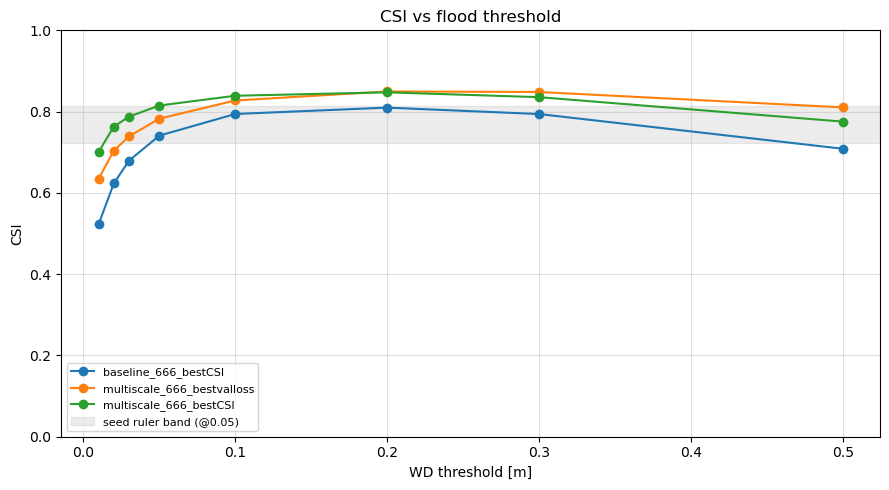

In [ ]:
# CSI vs threshold — all models, with the ruler band at 0.05 m
fig, ax = plt.subplots(figsize=(9, 5))
for name, r in results.items():
    ax.plot(r['csi_thresholds'], r['csi_curve'], 'o-', label=name)
ax.axhspan(RULER_LO, RULER_HI, xmin=0, xmax=1, color='grey', alpha=0.15, label='seed ruler band (@0.05)')
ax.set_xlabel('WD threshold [m]')
ax.set_ylabel('CSI')
ax.set_title('CSI vs flood threshold')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.4)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

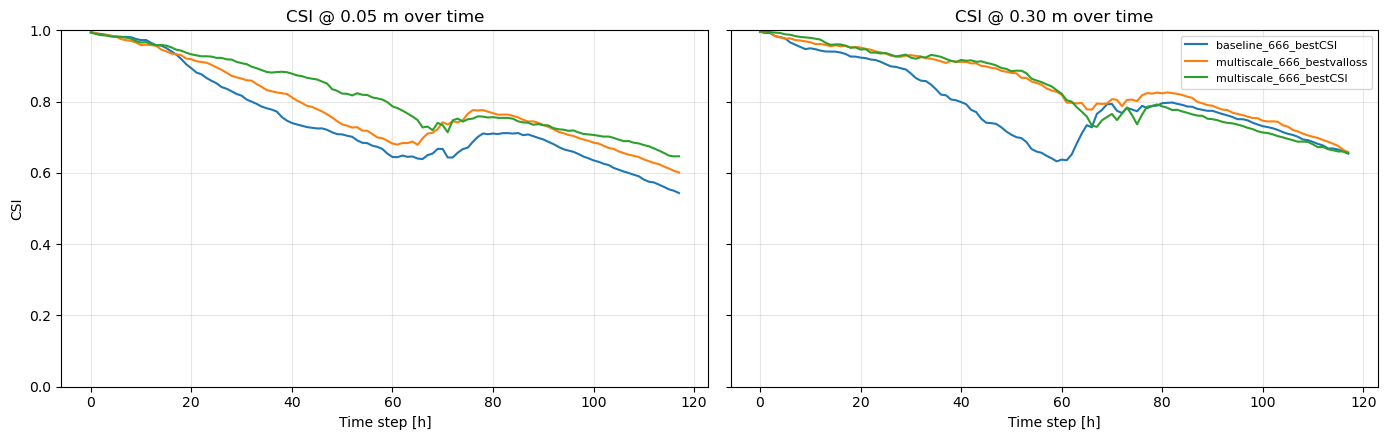

In [ ]:
# CSI over time — all models
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for name, r in results.items():
    axes[0].plot(r['csi_time_005'], label=name)
    axes[1].plot(r['csi_time_03'], label=name)
axes[0].set_title('CSI @ 0.05 m over time')
axes[1].set_title('CSI @ 0.30 m over time')
for ax in axes:
    ax.set_xlabel('Time step [h]')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('CSI')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## FP/FN decomposition @ 0.05 m
Same failure-mode diagnostics as the fixed-GT notebook: is the multiscale loss changing *where* the model fails,
or just the headline number? (rollout drift = growing FP; flood-front lag = FN in side valleys)

Diagnostic timesteps (of 118): {'rising limb': 71, 'peak': 76, 'recession': 117}


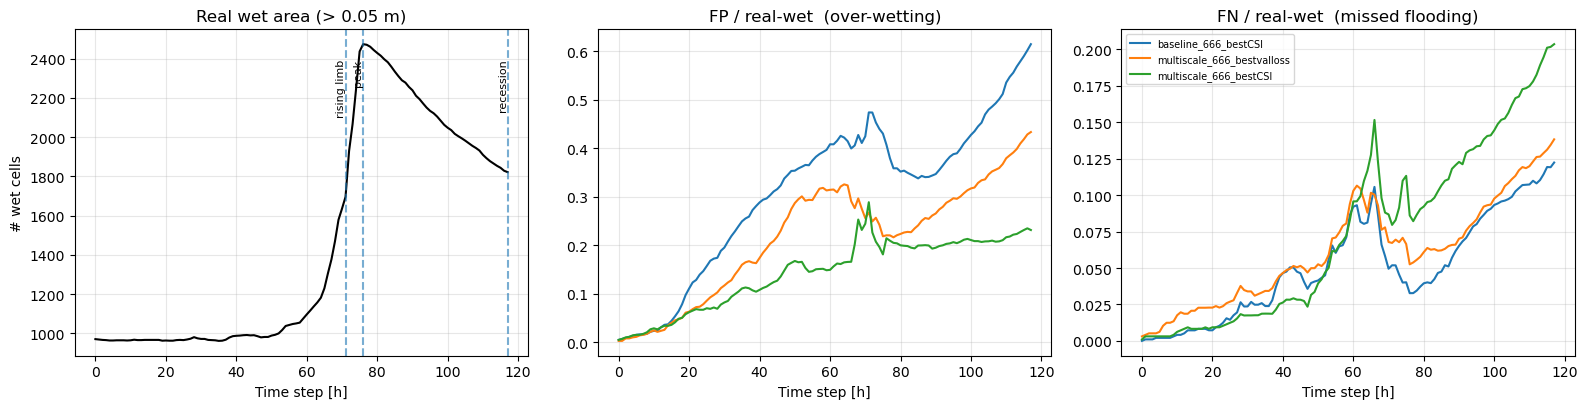

Model                         mean FP/wet  mean FN/wet  dominant error
baseline_666_bestCSI                0.308        0.051  FP (over-wetting)
multiscale_666_bestvalloss          0.215        0.062  FP (over-wetting)
multiscale_666_bestCSI              0.144        0.075  FP (over-wetting)


In [ ]:
from utils.miscellaneous import get_rollout_confusion_matrix

THR = 0.05  # m

real_s0 = next(iter(results.values()))['plot_rollout']._real_rollout_s0  # [nodes, vars, time]
wet_area = (real_s0[:, 0, :] > THR).sum(0).cpu().numpy()

t_peak = int(wet_area.argmax())
base = wet_area[0]
half = base + 0.5 * (wet_area.max() - base)
rise_c = np.where(wet_area[:t_peak] <= half)[0]
t_rise = int(rise_c[-1]) if len(rise_c) else max(t_peak // 2, 1)
rec_c = np.where(wet_area[t_peak:] <= half)[0]
t_rec = int(t_peak + rec_c[0]) if len(rec_c) else int(wet_area.shape[0] - 1)
phases = {'rising limb': t_rise, 'peak': t_peak, 'recession': t_rec}
print(f'Diagnostic timesteps (of {wet_area.shape[0]}):', phases)

conf = {}
for name, r in results.items():
    TP, TN, FP, FN = get_rollout_confusion_matrix(
        r['plot_rollout']._predicted_rollout_s0, r['plot_rollout']._real_rollout_s0,
        water_threshold=THR)
    conf[name] = dict(zip(['TP', 'TN', 'FP', 'FN'],
                          [v.cpu().numpy().astype(float) for v in (TP, TN, FP, FN)]))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].plot(wet_area, 'k-')
for ph, t in phases.items():
    axes[0].axvline(t, ls='--', alpha=0.6)
    axes[0].annotate(ph, (t, wet_area.max() * 0.97), rotation=90, fontsize=8, ha='right', va='top')
axes[0].set_title(f'Real wet area (> {THR} m)')
axes[0].set_ylabel('# wet cells')

for name, c in conf.items():
    wet = c['TP'] + c['FN']
    axes[1].plot(c['FP'] / wet, label=name)
    axes[2].plot(c['FN'] / wet, label=name)
axes[1].set_title('FP / real-wet  (over-wetting)')
axes[2].set_title('FN / real-wet  (missed flooding)')
for ax in axes:
    ax.set_xlabel('Time step [h]')
    ax.grid(alpha=0.3)
axes[2].legend(fontsize=7)
plt.tight_layout()
plt.show()

print(f"{'Model':<28} {'mean FP/wet':>12} {'mean FN/wet':>12}  dominant error")
for name, c in conf.items():
    wet = c['TP'] + c['FN']
    fp, fn = np.nanmean(c['FP'] / wet), np.nanmean(c['FN'] / wet)
    dom = 'FP (over-wetting)' if fp > fn else 'FN (under-prediction)'
    print(f"{name:<28} {fp:>12.3f} {fn:>12.3f}  {dom}")

### Spatial TP / FP / FN maps at rising limb, peak, recession
Red = false alarm (predicted wet, actually dry), orange = miss (predicted dry, actually wet).

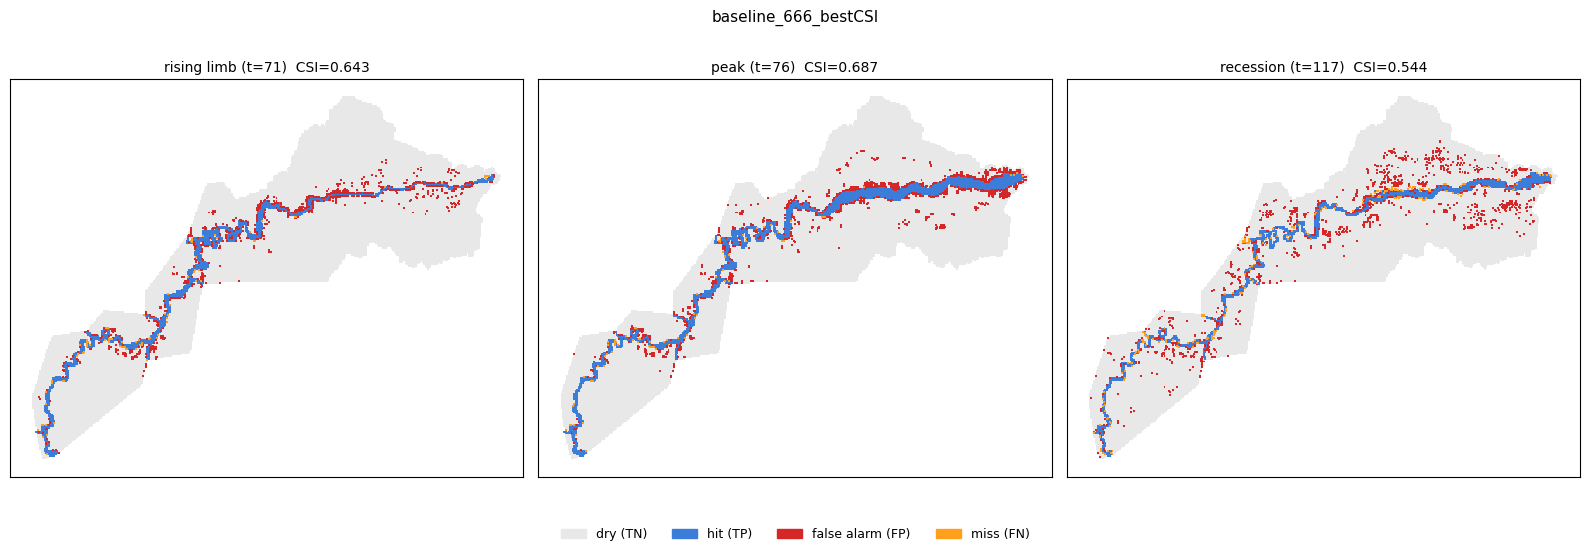

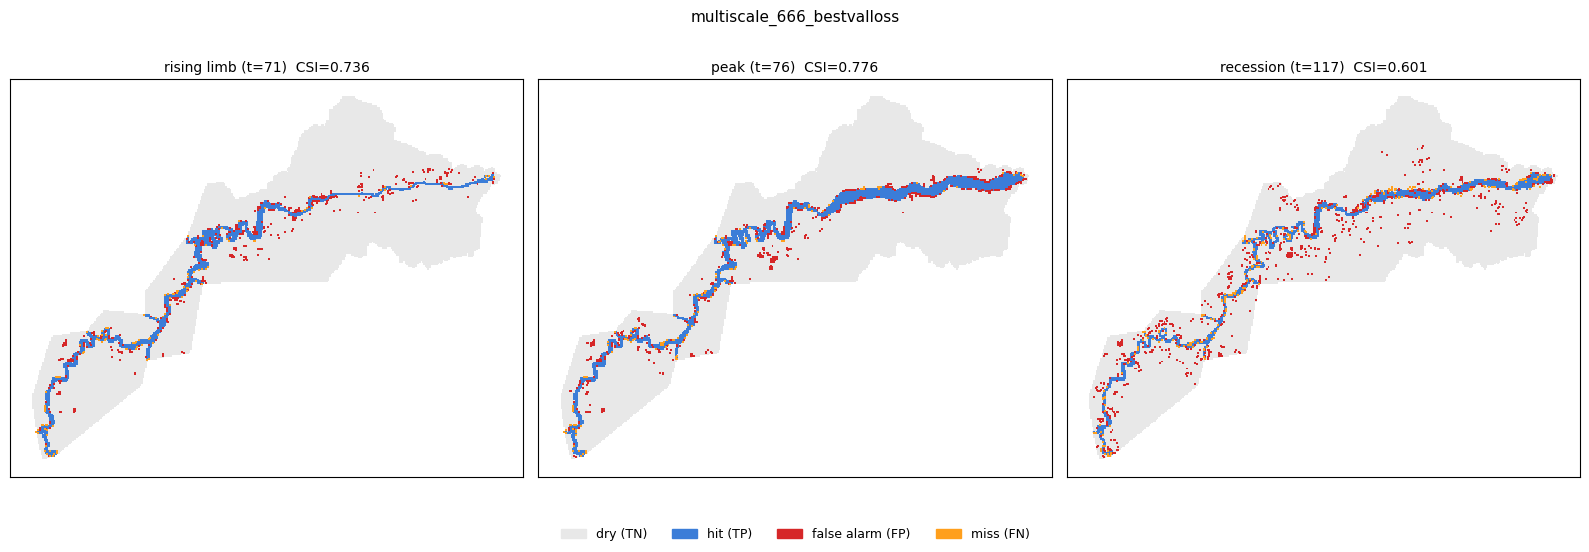

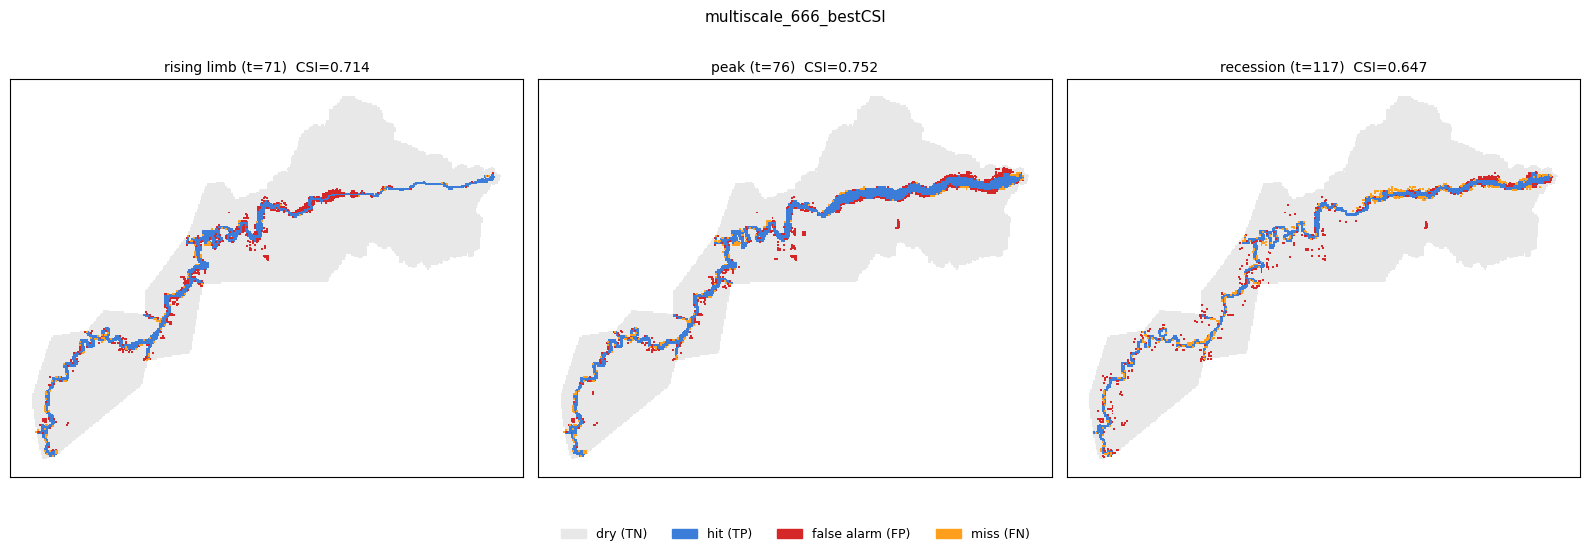

In [ ]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

n_s0 = real_s0.shape[0]
pos_s0 = np.asarray(test_dataset[0].mesh.face_xy)[:n_s0]

cat_cmap = ListedColormap(['#e8e8e8', '#3b7dd8', '#d62728', '#ff9f1c'])  # TN, TP, FP, FN
legend_handles = [Patch(color=c, label=l) for c, l in zip(
    cat_cmap.colors, ['dry (TN)', 'hit (TP)', 'false alarm (FP)', 'miss (FN)'])]

for name, r in results.items():
    pred = r['plot_rollout']._predicted_rollout_s0[:, 0, :].cpu().numpy()
    real = r['plot_rollout']._real_rollout_s0[:, 0, :].cpu().numpy()
    fig, axes = plt.subplots(1, len(phases), figsize=(16, 5.5))
    for ax, (ph, t) in zip(axes, phases.items()):
        p, g = pred[:, t] > THR, real[:, t] > THR
        cat = np.zeros(n_s0, dtype=int)
        cat[p & g] = 1
        cat[p & ~g] = 2
        cat[~p & g] = 3
        order = np.argsort(cat, kind='stable')
        ax.scatter(pos_s0[order, 0], pos_s0[order, 1], c=cat[order], cmap=cat_cmap,
                   vmin=0, vmax=3, s=2, marker='s', linewidths=0)
        csi_t = (p & g).sum() / max((p | g).sum(), 1)
        ax.set_title(f'{ph} (t={t})  CSI={csi_t:.3f}', fontsize=10)
        ax.set_aspect('equal')
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(name, fontsize=11)
    fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=9, frameon=False)
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.show()

--- baseline_666_bestCSI ---


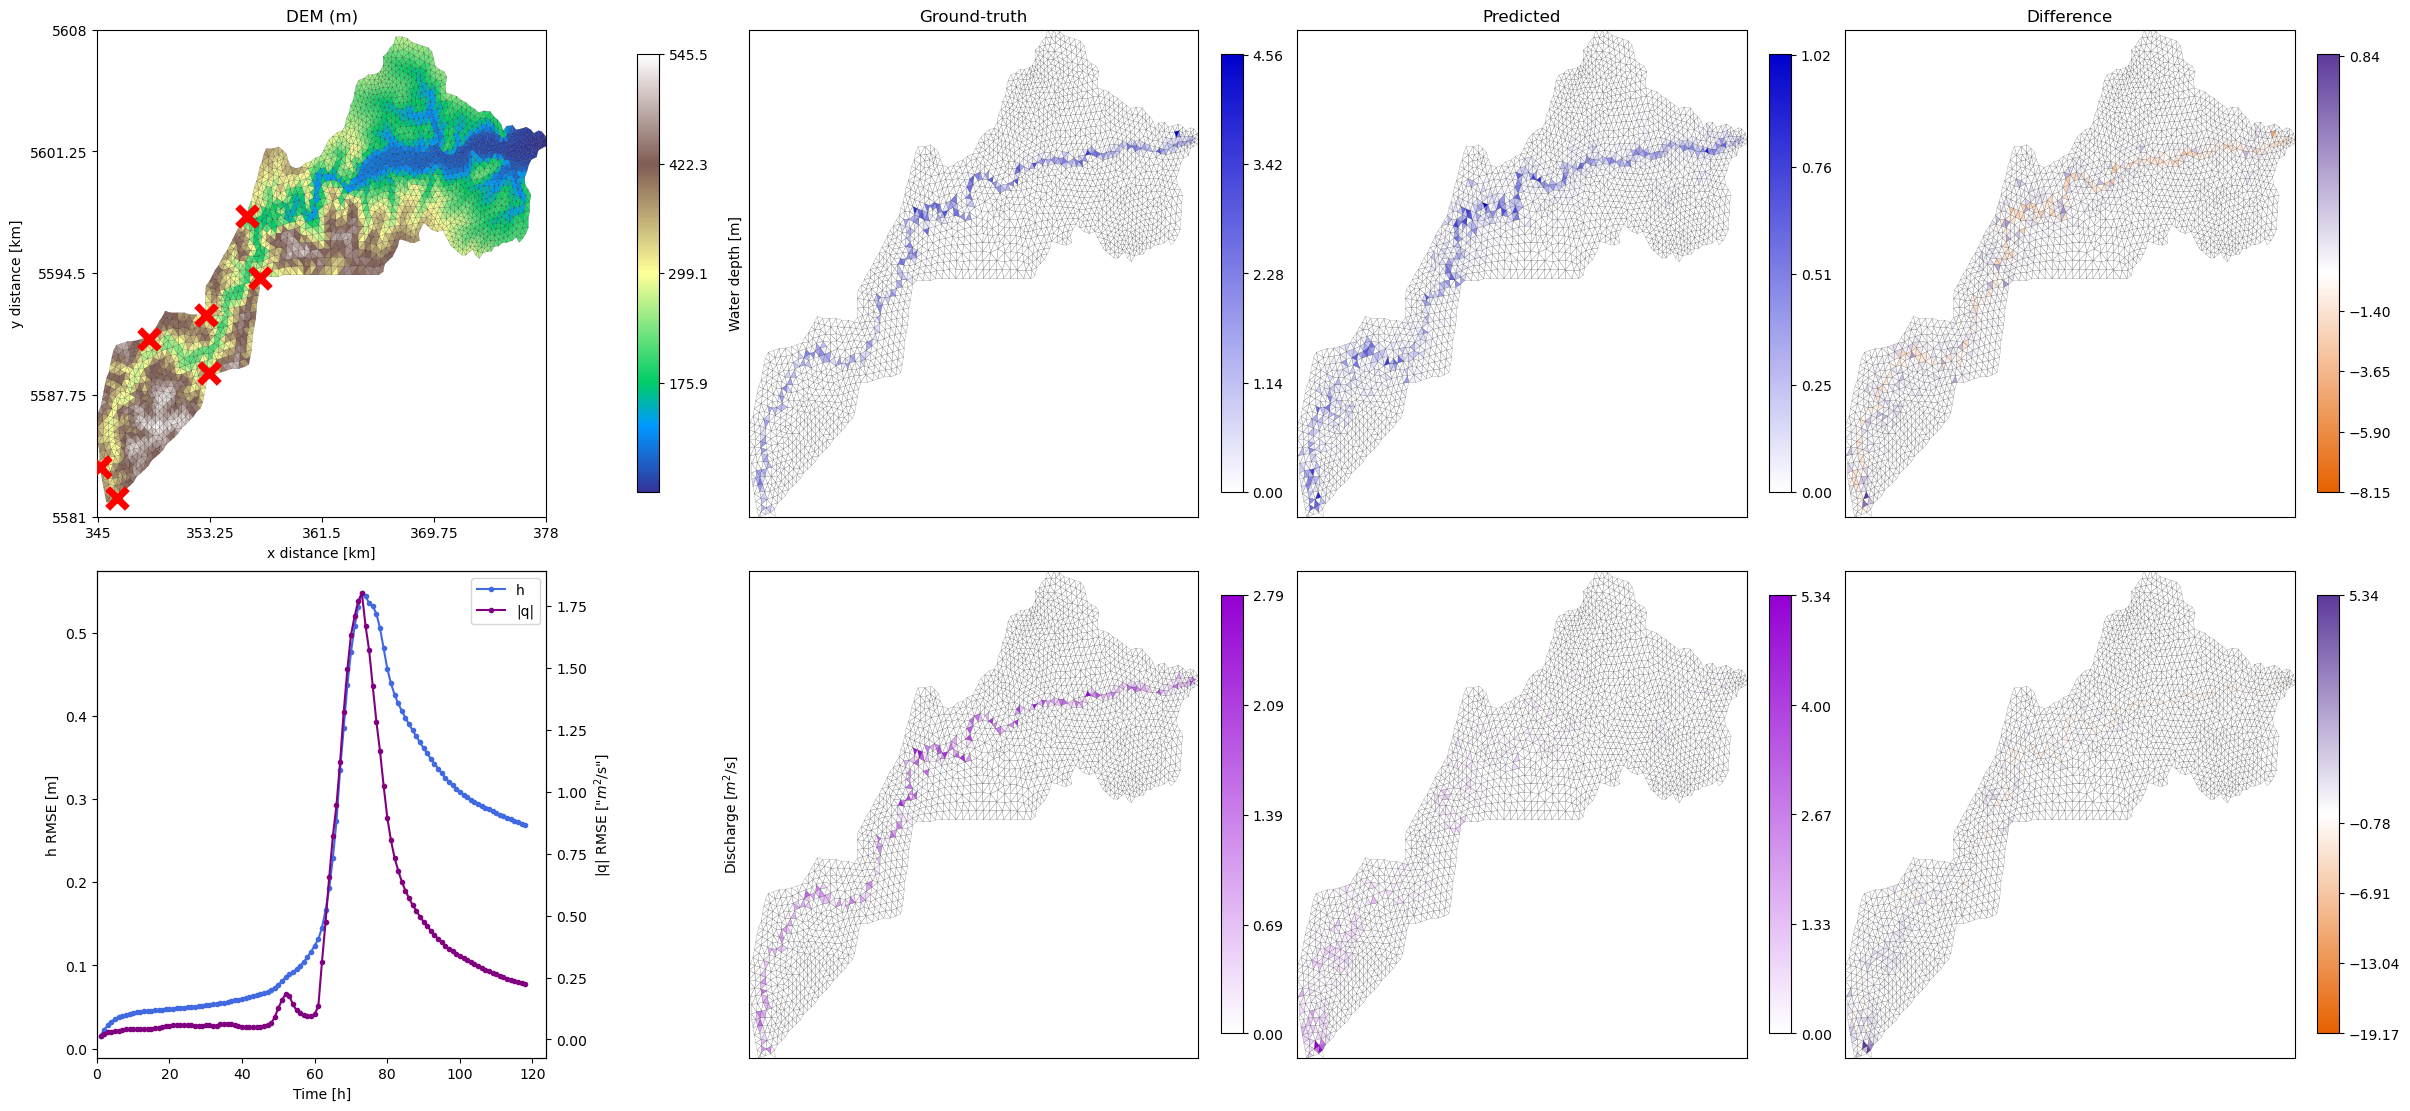

--- multiscale_666_bestvalloss ---


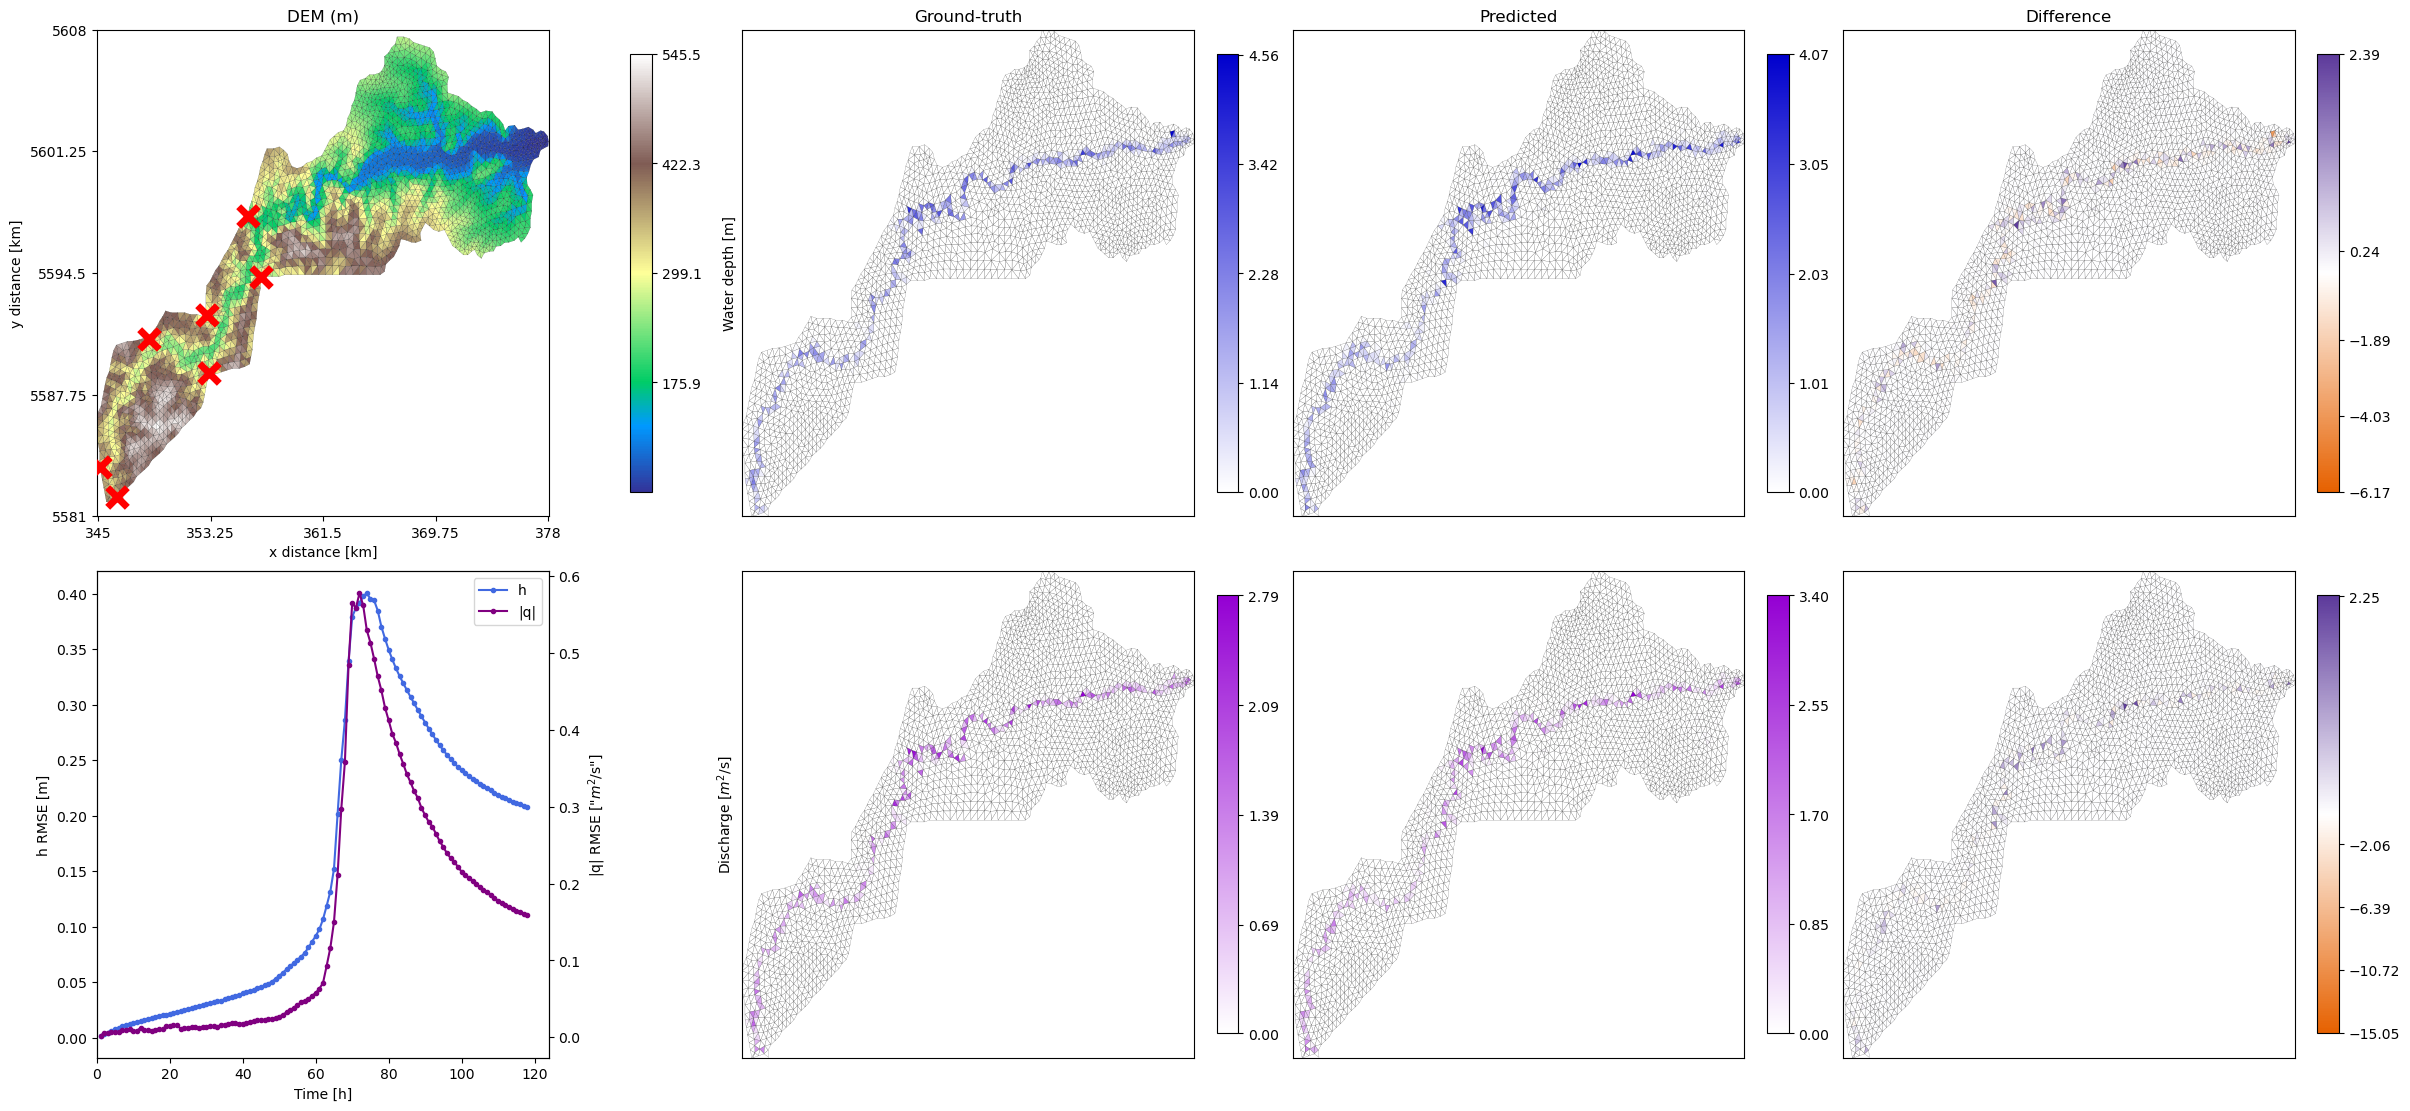

--- multiscale_666_bestCSI ---


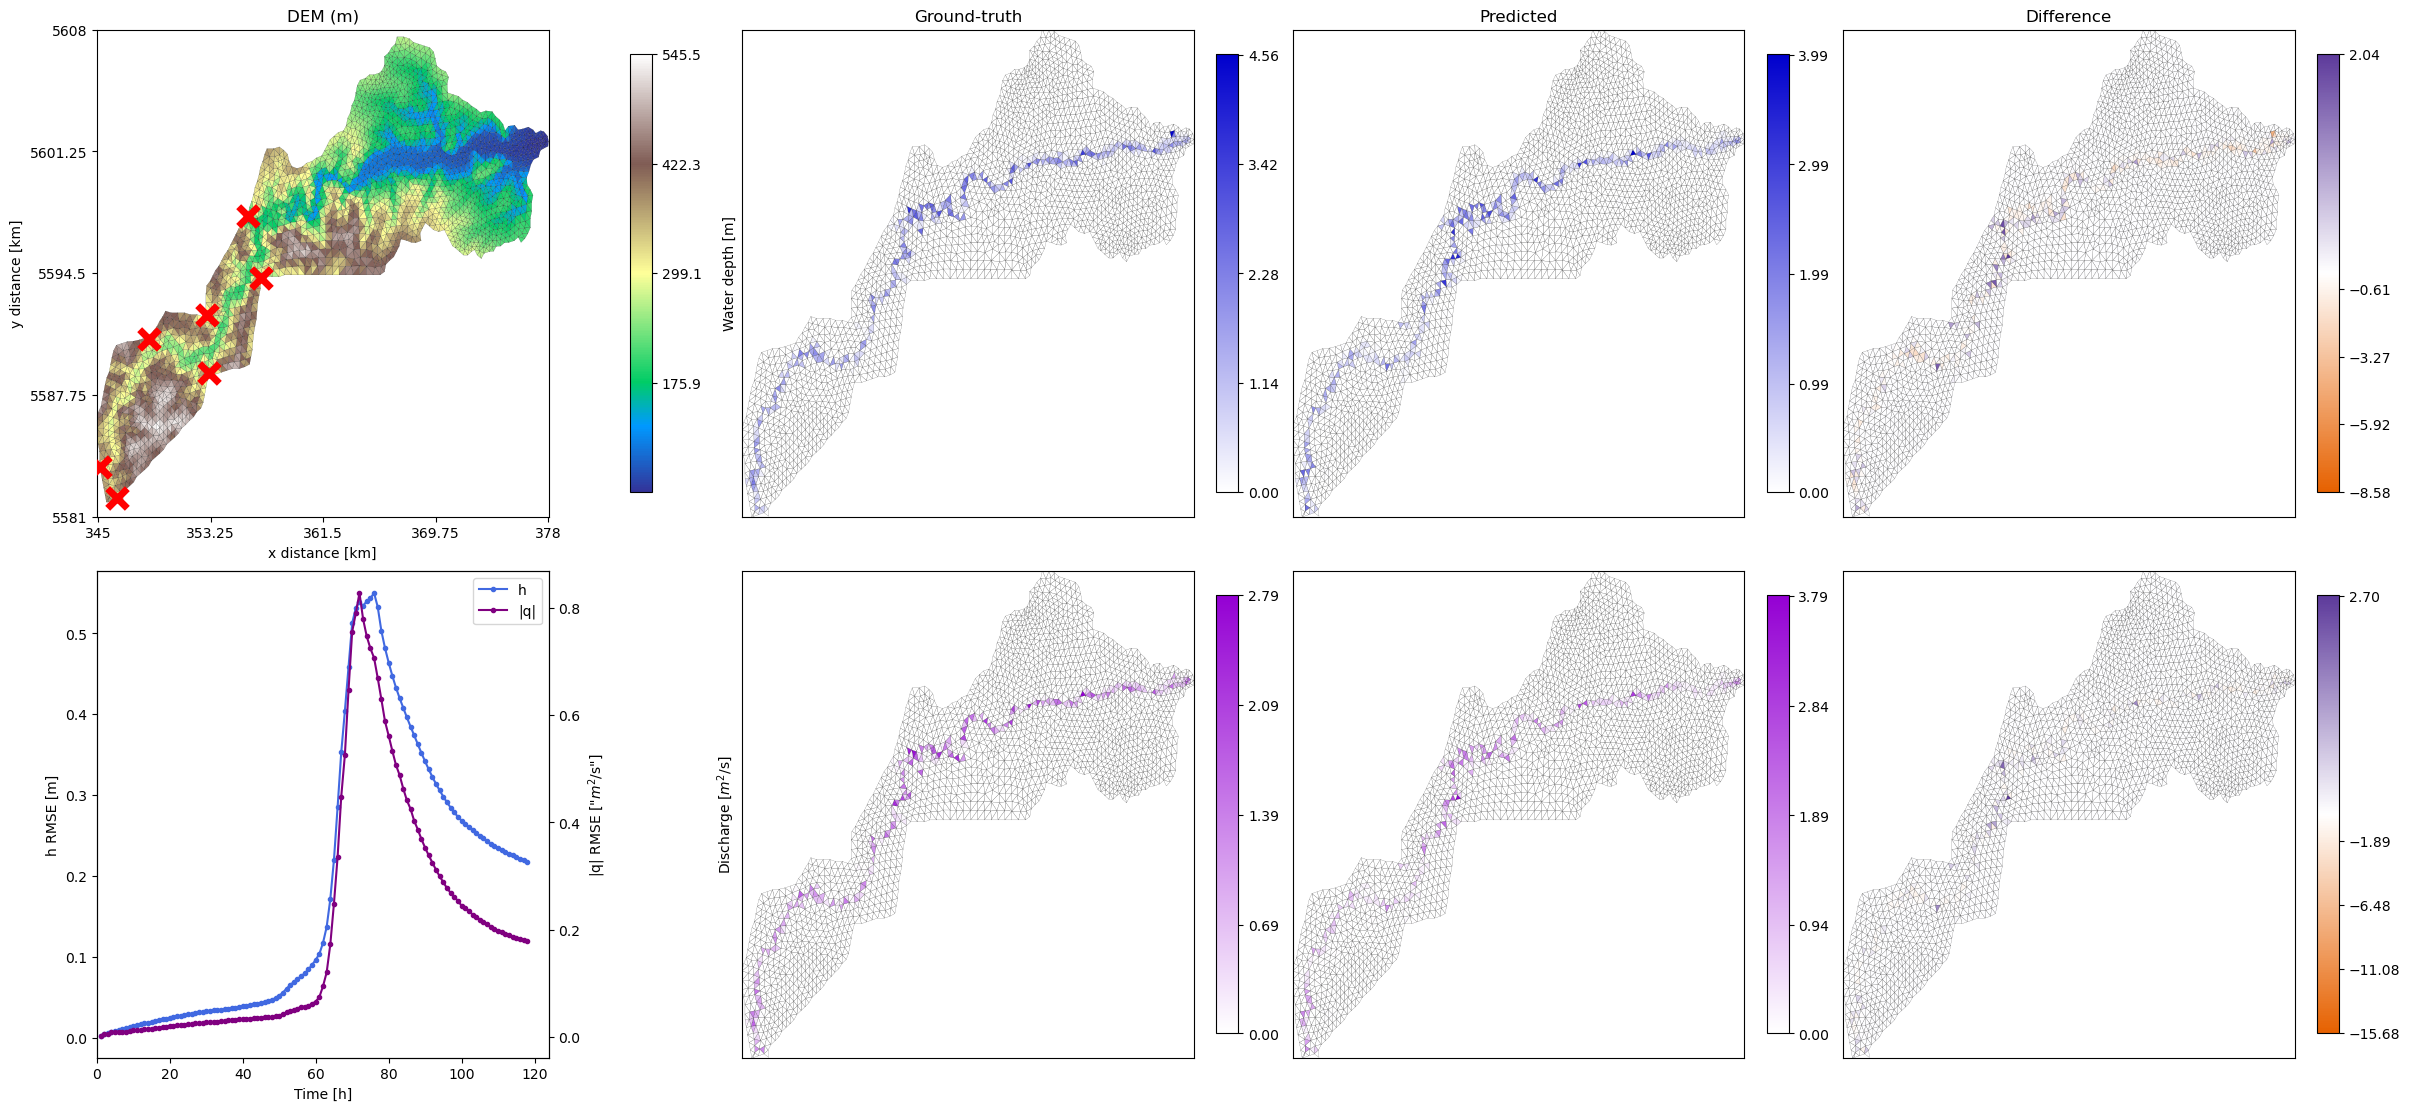

In [15]:
for name, r in results.items():
    print(f'--- {name} ---')
    fig = r['plot_rollout'].explore_rollout(scale=1, time_step=-1)
    plt.show()

--- baseline_666_bestCSI ---


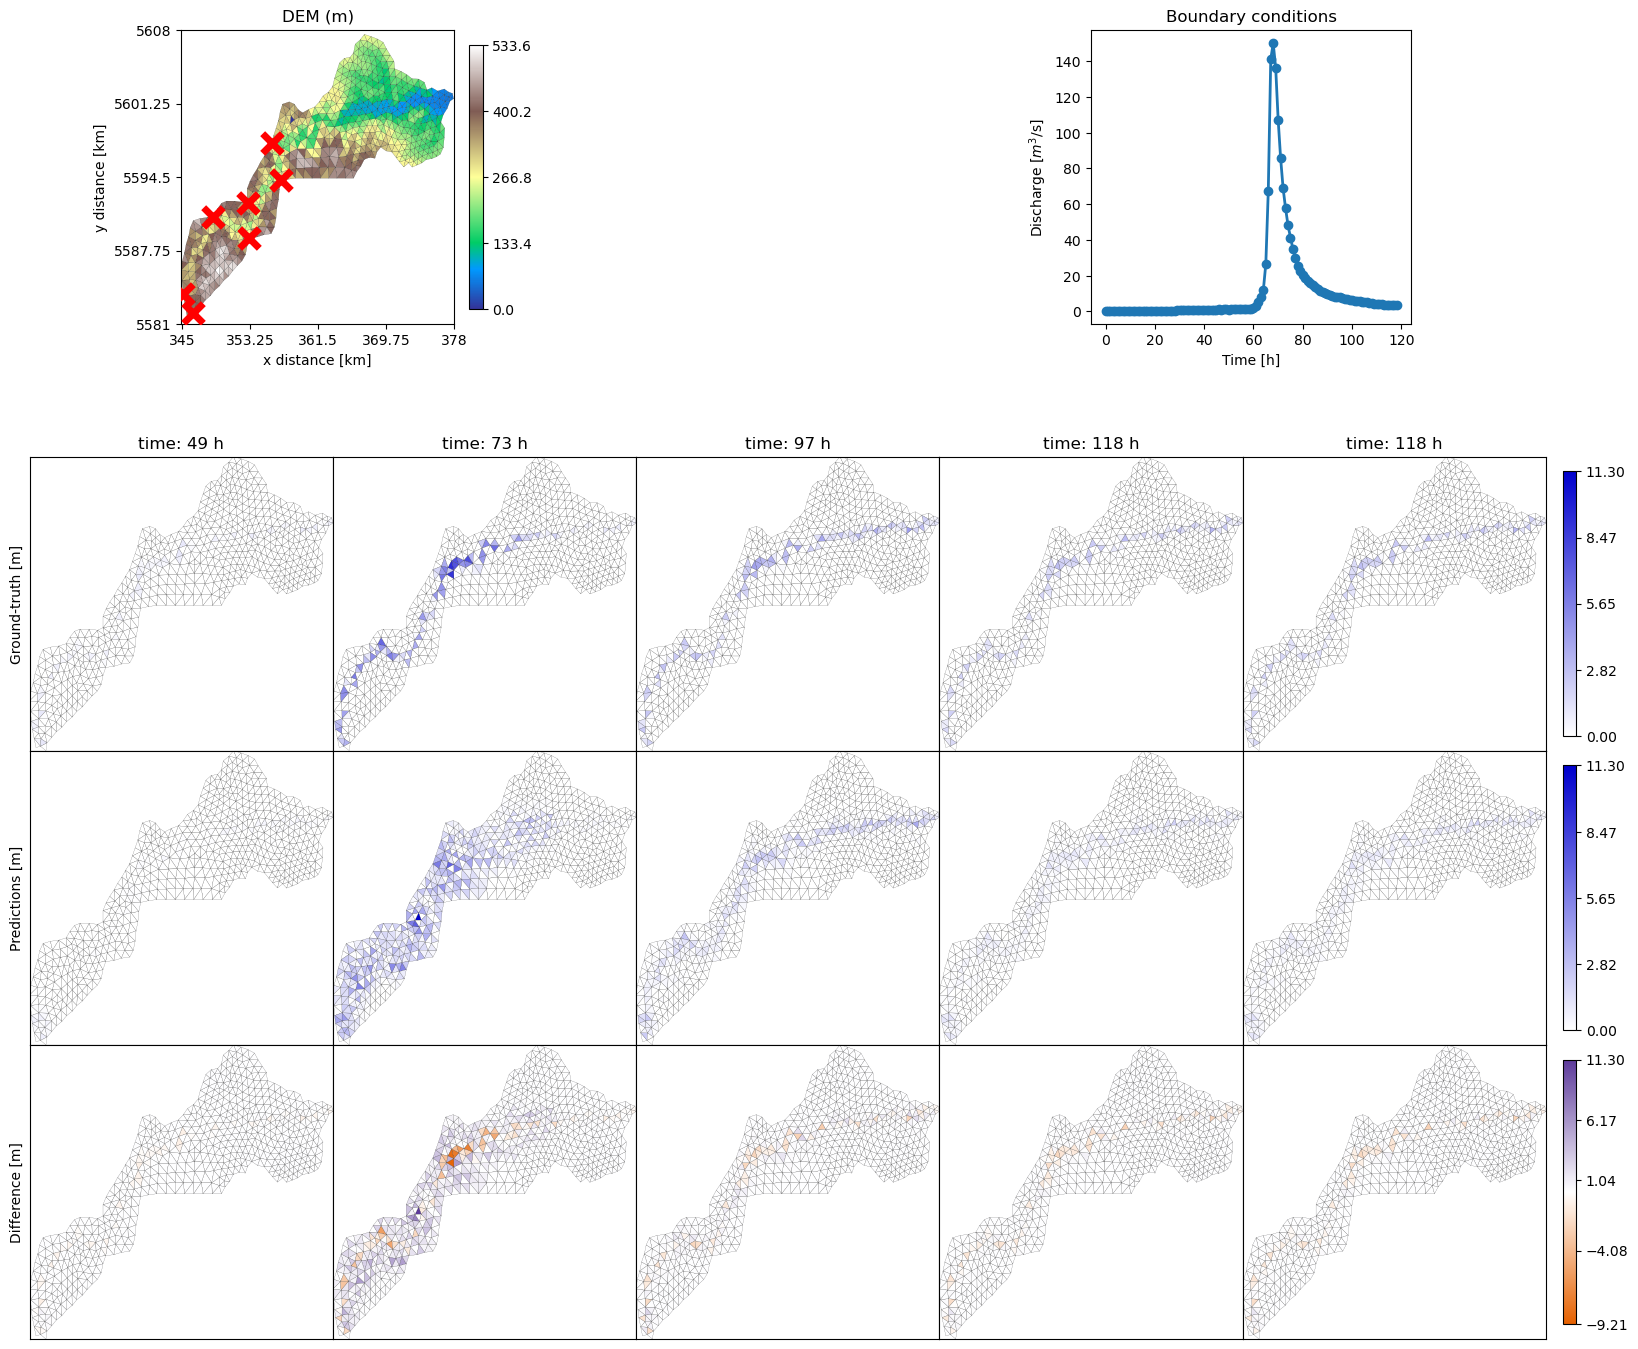

--- multiscale_666_bestvalloss ---


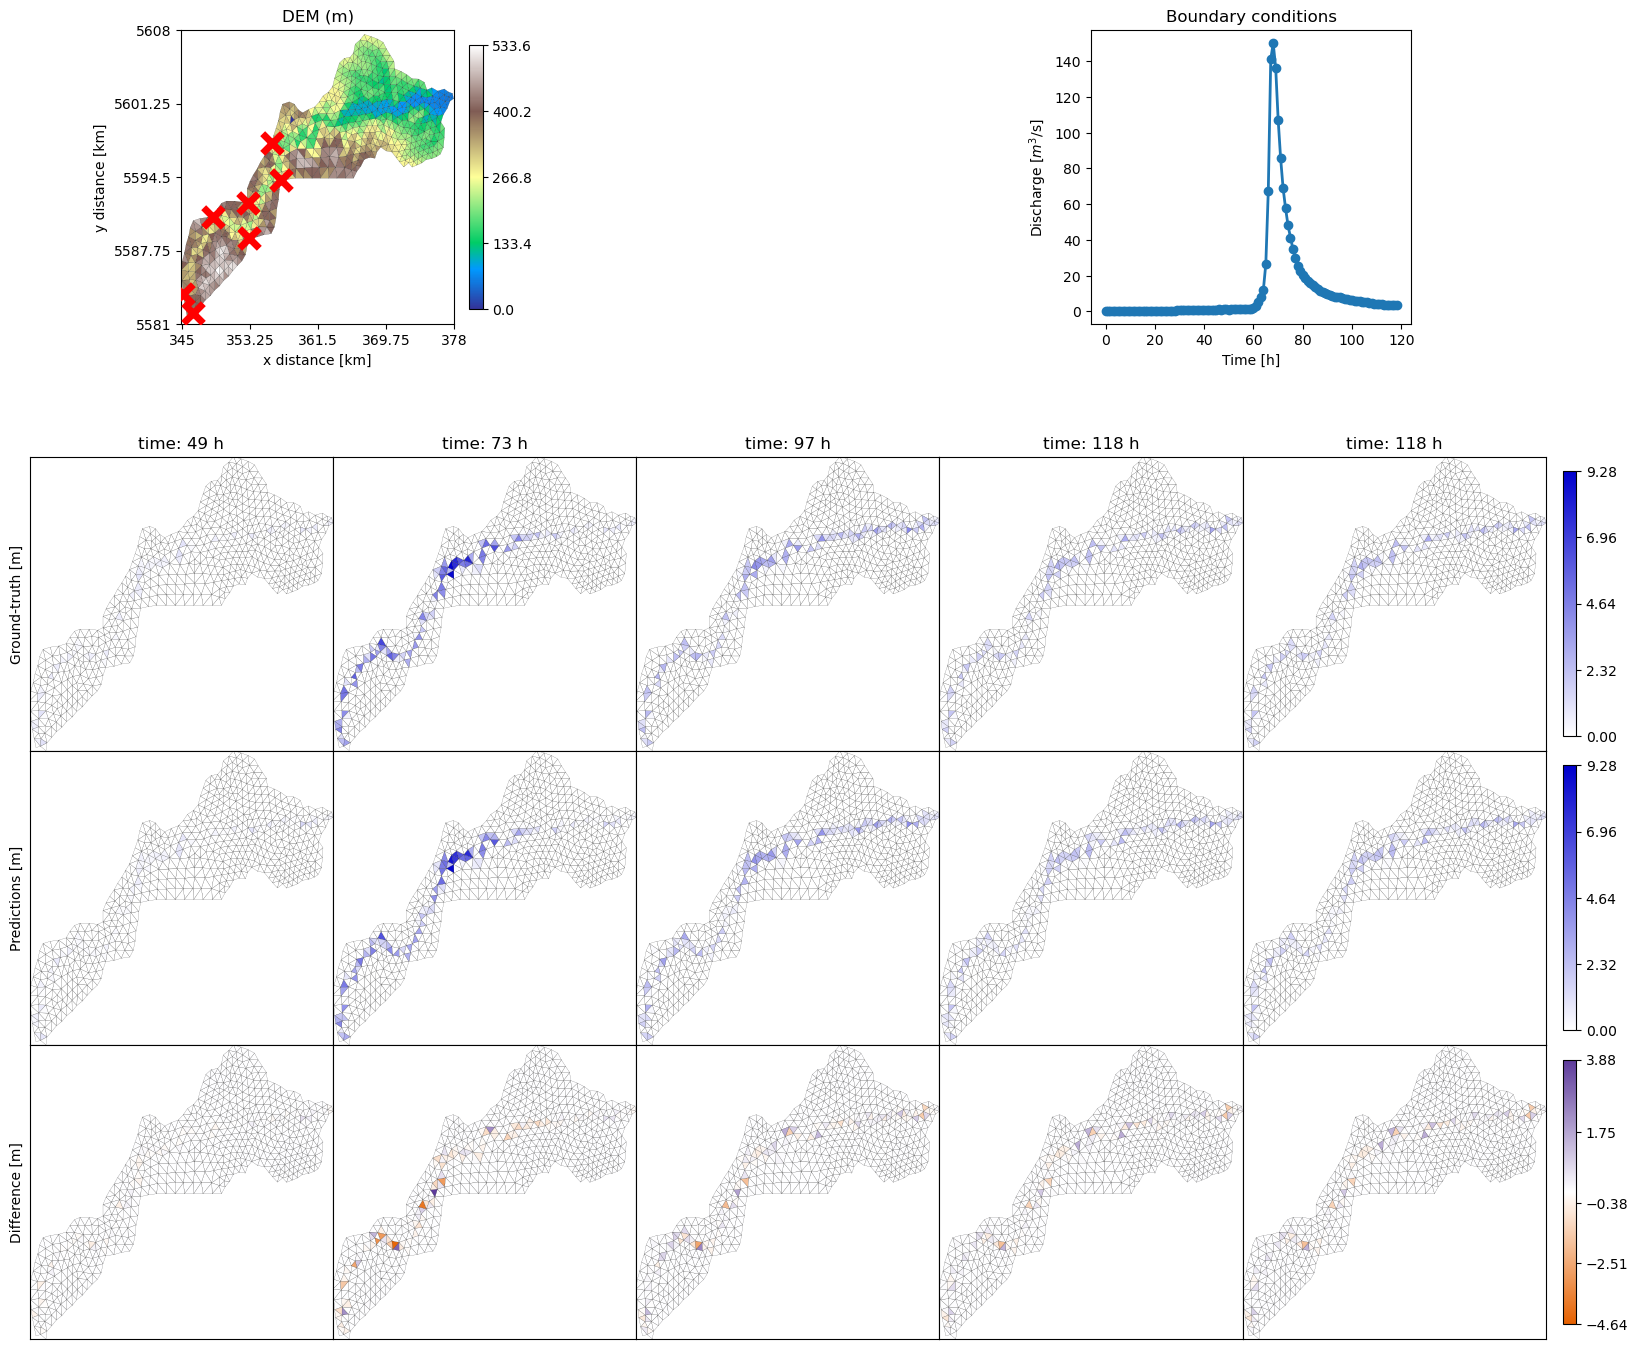

--- multiscale_666_bestCSI ---


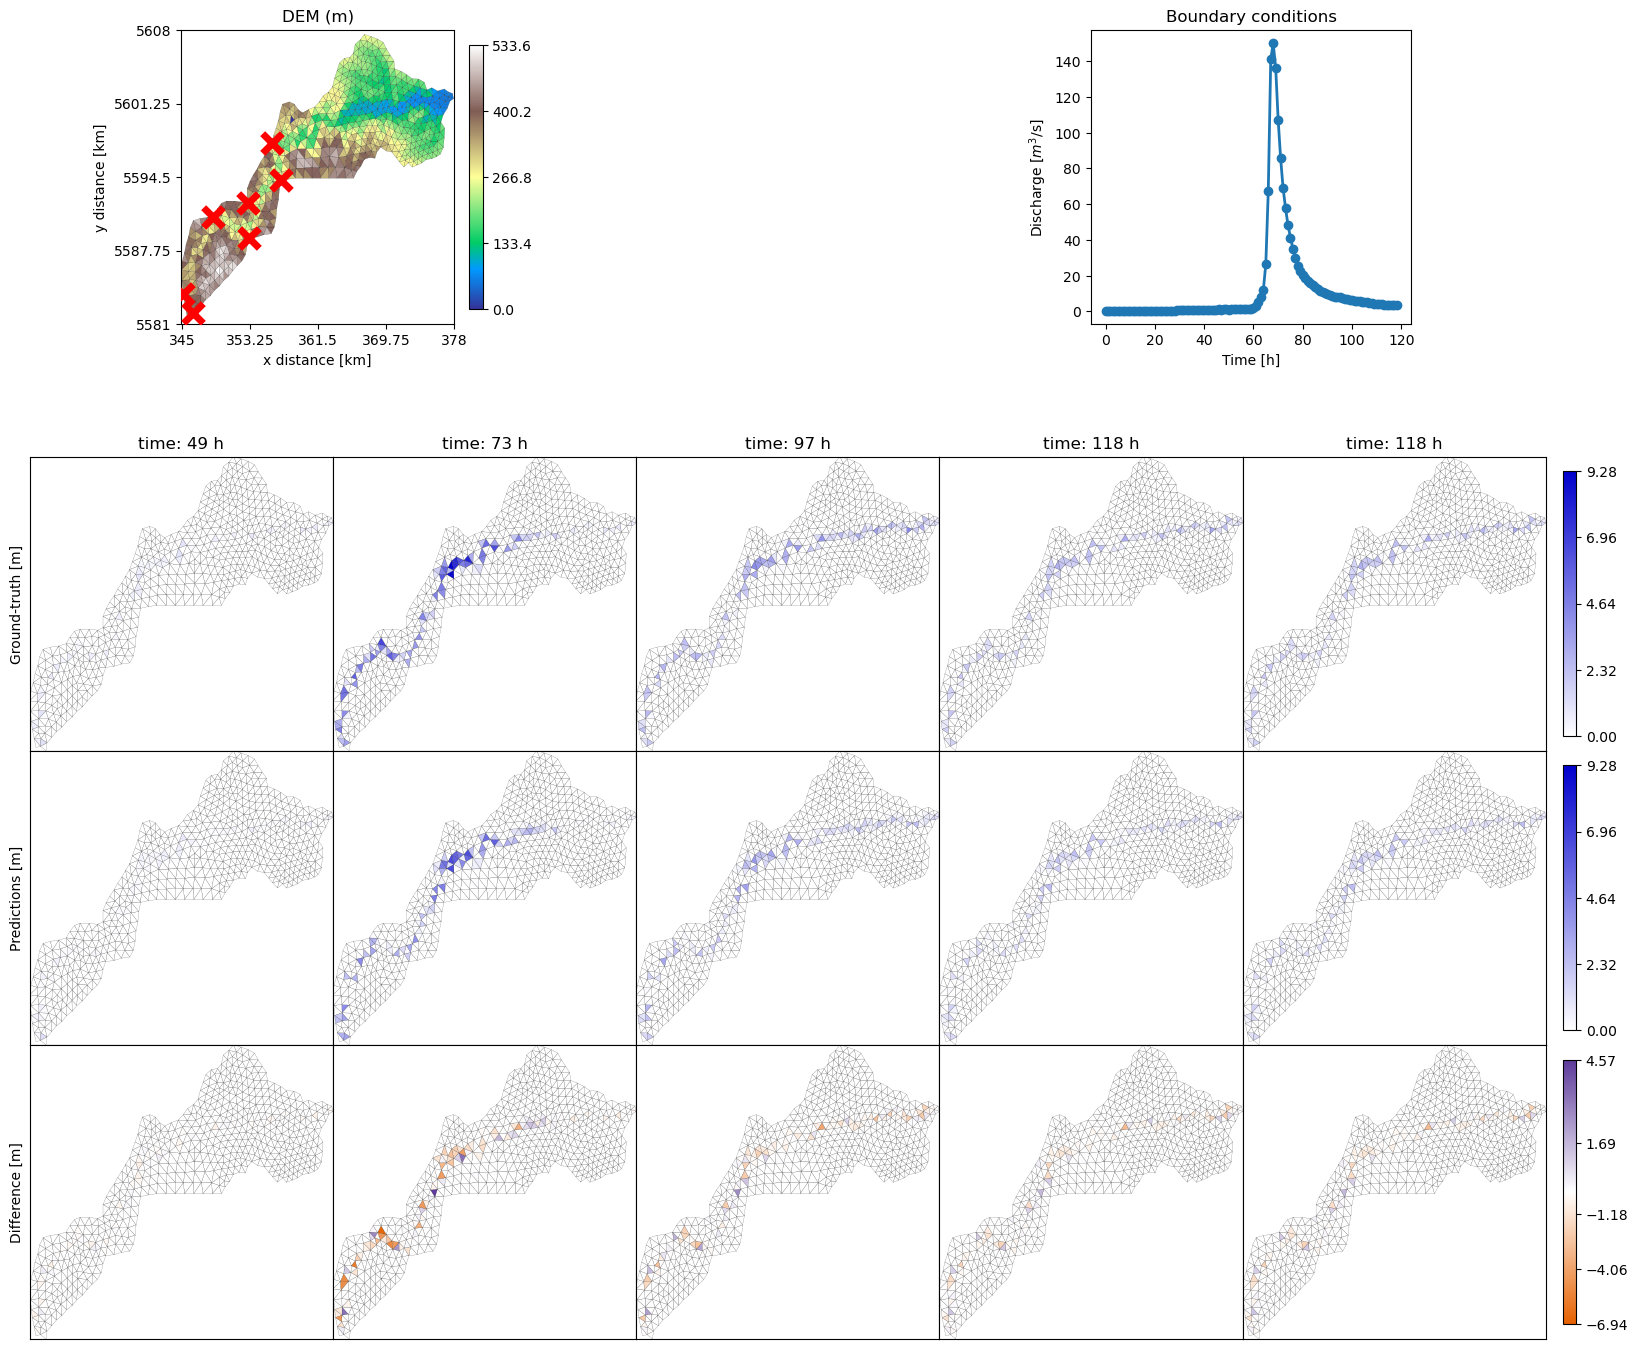

In [20]:
for name, r in results.items():
    print(f'--- {name} ---')
    n_steps = r['plot_rollout'].real_rollout.shape[-1]
    plot_times = [48, 72, 96, n_steps - 1]
    r['plot_rollout'].compare_h_rollout(plot_times=plot_times, scale=2)
    plt.show()

## Coarse-scale check (multiscale-specific)
The multiscale loss supervises scales 1-3 too. Quick check that the coarse-scale predictions became
sensible (they were unsupervised before): RMSE per scale for each model.

In [ ]:
from utils.dataset import separate_multiscale_node_features

node_ptr = test_dataset[0].node_ptr
num_scales = len(node_ptr) - 1

print(f"{'Model':<28} " + ' '.join(f'{f"RMSE_WD s{s}":>11}' for s in range(num_scales)))
for name, r in results.items():
    pred_scales = separate_multiscale_node_features(r['plot_rollout'].predicted_rollout, node_ptr)
    real_scales = separate_multiscale_node_features(r['plot_rollout'].real_rollout, node_ptr)
    rmses = []
    for s in range(num_scales):
        diff = (pred_scales[s][:, 0, :] - real_scales[s][:, 0, :])
        rmses.append(torch.sqrt((diff**2).mean()).item())
    print(f"{name:<28} " + ' '.join(f'{v:>11.4f}' for v in rmses))

Model                         RMSE_WD s0  RMSE_WD s1  RMSE_WD s2  RMSE_WD s3
baseline_666_bestCSI              0.2155      0.3766      0.4792      0.6186
multiscale_666_bestvalloss        0.1988      0.1953      0.1880      0.1370
multiscale_666_bestCSI            0.2433      0.2554      0.3200      0.2623
